In [1]:
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
# Muat dataset iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

### Data Understanding

In [3]:
# Identifikasi jumlah data
print("Jumlah data:", df.shape[0])

Jumlah data: 150


In [4]:
# Identifikasi tipe data
print("\nTipe data:")
print(df.dtypes)


Tipe data:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object


In [5]:
# Identifikasi nilai yang hilang
print("\nJumlah nilai yang hilang:")
print(df.isnull().sum())


Jumlah nilai yang hilang:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [6]:
# Identifikasi outlier (menggunakan IQR)
for column in df.columns[:-1]:  # Loop melalui fitur numerik
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  print(f"\nOutlier pada kolom {column}:")
  print(outliers)


Outlier pada kolom sepal length (cm):
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []

Outlier pada kolom sepal width (cm):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
15                5.7               4.4                1.5               0.4   
32                5.2               4.1                1.5               0.1   
33                5.5               4.2                1.4               0.2   
60                5.0               2.0                3.5               1.0   

    target  
15       0  
32       0  
33       0  
60       1  

Outlier pada kolom petal length (cm):
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []

Outlier pada kolom petal width (cm):
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []


In [8]:
# Deskripsi statistik data
print("\nDeskripsi statistik:")
df.describe()


Deskripsi statistik:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Cleansing Data

In [9]:
# 1. Pengisian nilai yang hilang (jika ada)
# Dalam dataset iris, tidak ada nilai yang hilang, jadi bagian ini bisa dilewati.
# Namun, jika ada, Anda bisa menggunakan:
# df['sepal length (cm)'].fillna(df['sepal length (cm)'].mean(), inplace=True) 
# df['sepal width (cm)'].fillna(df['sepal width (cm)'].median(), inplace=True)
# df['petal length (cm)'].fillna(df['petal length (cm)'].mode()[0], inplace=True)

In [10]:
# 2. Menghapus baris dengan data yang salah (jika ada)
# Dalam dataset iris, tidak ada data yang salah secara jelas.
# Namun, jika ada, Anda bisa menggunakan:
# df.drop(df[df['sepal length (cm)'] < 0].index, inplace=True)

In [11]:
# 3. Mengoreksi nilai outlier
for column in df.columns[:-1]:
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df[column] = df[column].clip(lower_bound, upper_bound)

In [12]:
# Setelah pembersihan data
print("\nDeskripsi statistik setelah pembersihan:")
df.describe()


Deskripsi statistik setelah pembersihan:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.00000,150.000000,150.000000,150.000000
mean,5.843333,3.05400,3.758000,1.199333,1.000000
std,0.828066,0.42539,1.765298,0.762238,0.819232
min,4.300000,2.05000,1.000000,0.100000,0.000000
25%,5.100000,2.80000,1.600000,0.300000,0.000000
50%,5.800000,3.00000,4.350000,1.300000,1.000000
75%,6.400000,3.30000,5.100000,1.800000,2.000000
max,7.900000,4.05000,6.900000,2.500000,2.000000


### Data Construction

In [13]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [14]:
# 1. Normalisasi data
# Normalisasi dilakukan menggunakan MinMaxScaler untuk mengubah rentang nilai fitur menjadi 0-1.
scaler = MinMaxScaler()
numerical_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
df[numerical_features] = scaler.fit_transform(df[numerical_features])
print("\nData setelah normalisasi:")
print(df.head())


Data setelah normalisasi:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           0.222222             0.725           0.067797          0.041667   
1           0.166667             0.475           0.067797          0.041667   
2           0.111111             0.575           0.050847          0.041667   
3           0.083333             0.525           0.084746          0.041667   
4           0.194444             0.775           0.067797          0.041667   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [15]:
# 2. Pemilihan fitur
# Menggunakan SelectKBest untuk memilih 2 fitur terbaik berdasarkan skor ANOVA F-value.
X = df.drop('target', axis=1)
y = df['target']
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("\nFitur terpilih:", selected_features)


Fitur terpilih: Index(['petal length (cm)', 'petal width (cm)'], dtype='object')


In [ ]:
# 3. Binning
# Binning dilakukan pada fitur 'petal length (cm)' untuk mengelompokkan data menjadi beberapa kategori.
df['petal_length_binned'] = pd.cut(df['petal length (cm)'], bins=3, labels=['rendah', 'sedang', 'tinggi'])


Data setelah binning:


In [17]:
print("\nData setelah binning:")
df.head()


Data setelah binning:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,petal_length_binned
0,0.222222,0.725,0.067797,0.041667,0,rendah
1,0.166667,0.475,0.067797,0.041667,0,rendah
2,0.111111,0.575,0.050847,0.041667,0,rendah
3,0.083333,0.525,0.084746,0.041667,0,rendah
4,0.194444,0.775,0.067797,0.041667,0,rendah


### Selecting Label Data

In [18]:
# Identifikasi data target dan lakukan pelabelan
# Dalam dataset iris, kolom 'target' sudah mewakili label kelas (0, 1, 2).
# Namun, jika diperlukan pelabelan yang lebih spesifik berdasarkan SOP,
# kita bisa melakukan mapping label sesuai dengan kebutuhan.

In [19]:
# Misalnya, jika SOP menentukan bahwa:
# - target 0: Setosa
# - target 1: Versicolor
# - target 2: Virginica
# Kita bisa membuat mapping label seperti ini:

label_mapping = {
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
}

In [20]:
# Buat kolom baru 'target_label' yang berisi label teks
df['target_label'] = df['target'].map(label_mapping)

In [21]:
# Tampilkan data dengan label baru
print("\nData dengan label berdasarkan SOP:")
df.head()


Data dengan label berdasarkan SOP:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,petal_length_binned,target_label
0,0.222222,0.725,0.067797,0.041667,0,rendah,Setosa
1,0.166667,0.475,0.067797,0.041667,0,rendah,Setosa
2,0.111111,0.575,0.050847,0.041667,0,rendah,Setosa
3,0.083333,0.525,0.084746,0.041667,0,rendah,Setosa
4,0.194444,0.775,0.067797,0.041667,0,rendah,Setosa


### Data Vizualitation

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Histogram untuk melihat distribusi data setelah pembersihan
# Adjust the subplot grid to accommodate all columns
num_cols = len(df.columns[:-2])
num_rows = (num_cols + 1) // 2  # Calculate rows needed
plt.figure(figsize=(12, 6 * num_rows)) # Adjust figure height 

<Figure size 1200x1800 with 0 Axes>

<Figure size 1200x1800 with 0 Axes>

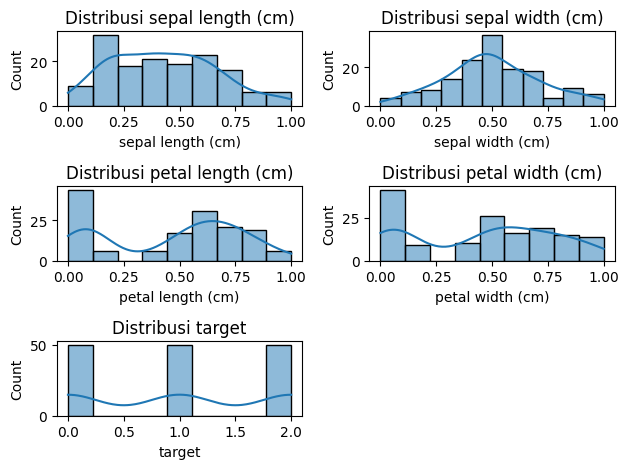

In [24]:
for i, column in enumerate(df.columns[:-2]):  # Loop melalui fitur numerik
  plt.subplot(num_rows, 2, i + 1)  # Use calculated rows and cols
  sns.histplot(df[column], kde=True)
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

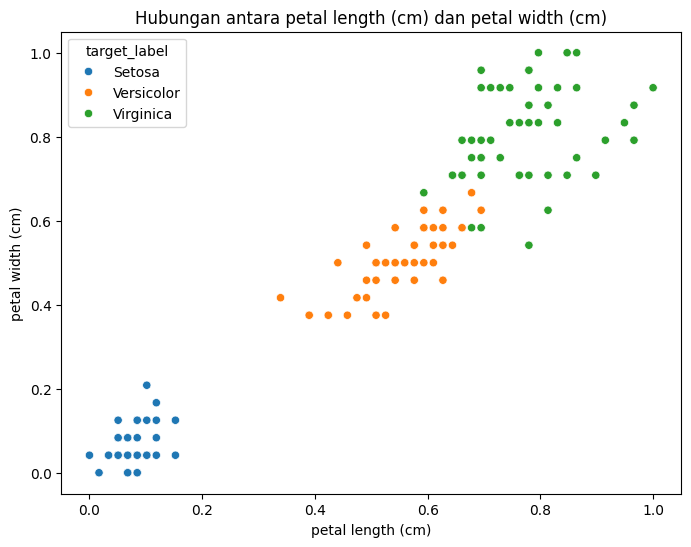

In [25]:
# Scatter plot untuk melihat hubungan antara dua fitur terpilih
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[selected_features[0]], y=df[selected_features[1]], hue=df['target_label'])
plt.title(f'Hubungan antara {selected_features[0]} dan {selected_features[1]}')
plt.show()

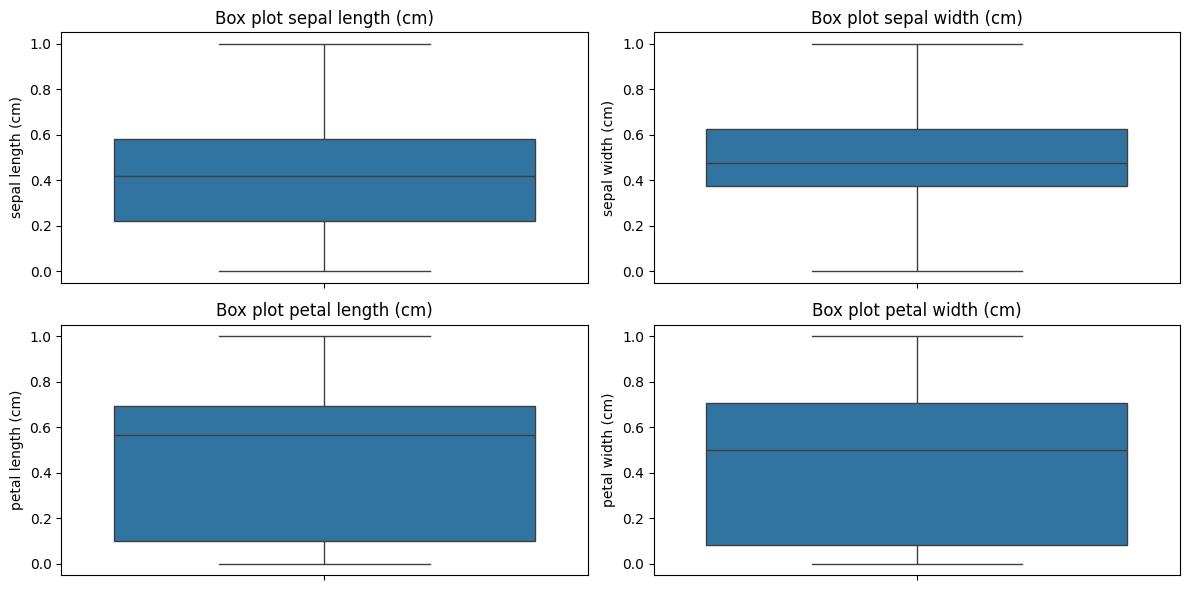

In [26]:
# Box plot untuk melihat distribusi data sebelum dan sesudah normalisasi
plt.figure(figsize=(12, 6))
for i, column in enumerate(numerical_features):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(data=df, y=column)
  plt.title(f'Box plot {column}')
plt.tight_layout()
plt.show()

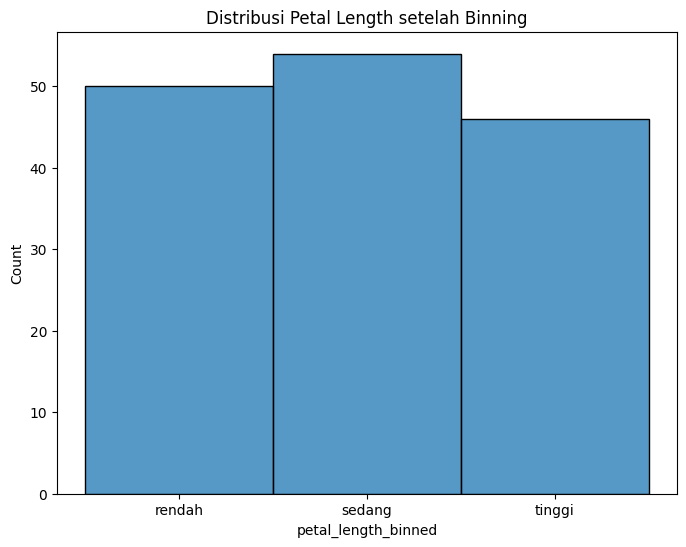

In [27]:
# Histogram untuk melihat distribusi data setelah binning
plt.figure(figsize=(8, 6))
sns.histplot(df['petal_length_binned'], kde=False)
plt.title('Distribusi Petal Length setelah Binning')
plt.show()

In [28]:
print("\nStatistik Deskriptif Data Setelah Pembersihan:")
df.describe()


Statistik Deskriptif Data Setelah Pembersihan:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.502000,0.467458,0.458056,1.000000
std,0.230018,0.212695,0.299203,0.317599,0.819232
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.375000,0.101695,0.083333,0.000000
50%,0.416667,0.475000,0.567797,0.500000,1.000000
75%,0.583333,0.625000,0.694915,0.708333,2.000000
max,1.000000,1.000000,1.000000,1.000000,2.000000
